In [89]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operation with MCP Neuron for two inputs.

    Arguments:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.

    Output:
    state_neuron (list): State of neuron (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [90]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2 # Threshold value
# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)
# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [91]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.

    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.

    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the given inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise addition and threshold check
    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron



In [92]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1 # Threshold value for OR gate
# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)
# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


# Question 1:
List out all the limitation of MCP- Neurons


*   They can only handle simple, linearly separable problems, so they don’t work for cases like XOR.
* They don’t have any learning ability, meaning we have to manually set the weights and threshold

* The output is only binary (0 or 1), which makes them too basic for more complex tasks

* They can’t capture non-linear relationships between inputs

* They are not flexible or adaptive since they don’t improve from data or errors




# Question 2
Think if you can develop a logic to solve for XOR function using MCP Neuron.

Ans: A single MCP neuron cannot solve the XOR function because it is not linearly separable. However, XOR can be implemented by combining multiple MCP neurons or by using logical conditions. In simple terms, XOR outputs 1 when the inputs are different, which can be expressed using an if-else rule like: if X1 is not equal to X2, output 1, otherwise output 0.

# The Perceptron

# Task 2: Perceptron Algorithm for 0 vs 1 Classification.

In [93]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/Ai and Ml/mnist_0_and_1.csv")
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


# Question - 1: What does the shape of X represent?

The shape of X shows how the dataset is organized in terms of rows and columns. The rows represent the total number of images or samples in the dataset, while the columns represent the features of each image. Here, each image is converted into 784 features, which correspond to its pixel values.

# Question - 2: What does the shape of Y represent?

The shape of y represents the label vector containing the target values for each sample in the dataset. Since each image in X corresponds to one label, the shape of y is (n,), where n is the total number of samples. Each element in y indicates whether the corresponding image is a digit 0 or 1, so it essentially stores the output or classification for every input image in the dataset.

# Visualizing the Dataset.

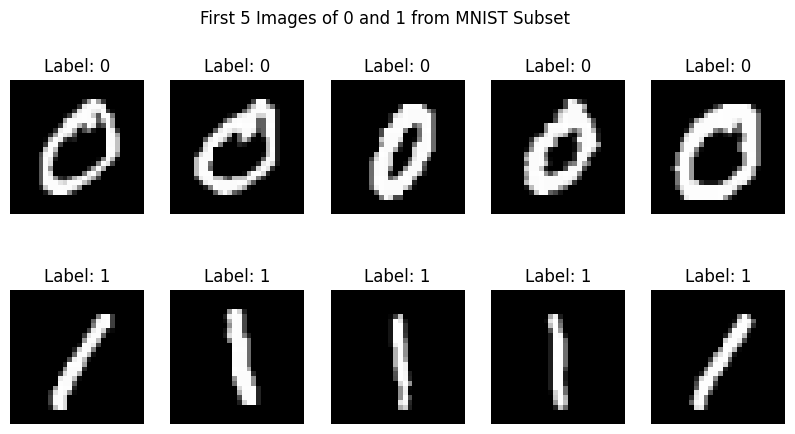

In [94]:
import matplotlib.pyplot as plt

# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have enough data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

# Initialization of the Weights:

In [95]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

# Question - 3: What does the weights array represent in this context?

The weights array represents the importance assigned to each input feature (pixel) when making a prediction. Since each image has 784 pixels, there are 784 corresponding weights, where each weight determines how much influence a specific pixel has on the final output. During training, these weights are adjusted so that the model can correctly distinguish between digits 0 and 1 based on the pixel values.

# Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?

Initializing the weights to zero provides a simple and neutral starting point for the model before training begins. It ensures that all features start with equal importance, and the model learns from scratch by updating the weights through the training process. In models like logistic regression or perceptron, this does not cause major issues because the weights are updated using the data and gradients. However, in more complex models like neural networks, initializing all weights to zero can prevent learning because all neurons would behave the same and update identically, leading to a lack of meaningful feature learning.

# Implementation Decision Function:

In [96]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """

    predictions = np.dot(X, weights) + bias

    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

# Training the Perceptron:

In [97]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    Parameters:
  - X: Features (input data) as a numpy array of shape (n_samples, n_features)
  - y: Labels (true output) as a numpy array of shape (n_samples,)
  - weights: Initial weights as a numpy array of shape (n_features,)
  - bias: Initial bias value (scalar)
  - learning_rate: Learning rate for weight updates (default is 0.1)
  - epochs: Number of iterations to train the model (default is 100)
    Returns:
  - weights: Updated weights after training
  - bias: Updated bias after training
  - accuracy: Total correct prediction.
      """

    for epoch in range(epochs):
        for i in range(len(X)):
            # Step 1: Linear combination
            output = np.dot(X[i], weights) + bias

            # Step 2: Activation (step function)
            prediction = 1 if output >= 0 else 0

            # Step 3: Update if wrong
            if prediction != y[i]:
                weights = weights + learning_rate * (y[i] - prediction) * X[i]
                bias = bias + learning_rate * (y[i] - prediction)

    # Calculate accuracy
    correct = 0
    for i in range(len(X)):
        output = np.dot(X[i], weights) + bias
        prediction = 1 if output >= 0 else 0
        if prediction == y[i]:
            correct += 1

    accuracy = correct / len(X)

    return weights, bias, accuracy

# Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

The line output = np.dot(X[i], weights) + bias computes the linear combination of the input features and their corresponding weights, along with the bias term. It represents the model’s raw prediction score for a given input sample before applying the activation (step) function. This value determines on which side of the decision boundary the input lies, helping the model decide whether to classify it as 0 or 1.

# Question - 6: What happens when the prediction is wrong? How are the weights and bias updated?

When the prediction is wrong, the perceptron updates its weights and bias to reduce future errors. The update is based on the difference between the true label and the predicted label, calculated as learning_rate * (y[i] - y_pred). The weights are adjusted by adding this update multiplied by the input features, and the bias is updated by adding the same update value. This process shifts the decision boundary so that the model becomes more likely to correctly classify that sample in future iterations.

# Question - 7:Why is the final accuracy important, and what do you expect it to be?

The final accuracy is important because it measures how well the trained perceptron performs on the dataset by indicating the proportion of correctly classified samples. A higher accuracy means the model has learned the pattern in the data effectively. Since the task involves distinguishing between two simple digits (0 and 1), which are usually linearly separable, we expect the final accuracy to be very high,often close to or equal to 100% if the model is trained properly.

# Training the Perceptron Algorithm:

In [98]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


# Visualizing Misclassified Image.

In [99]:
import matplotlib.pyplot as plt

# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show up to 10
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


# Question - 8:What does misclassified idx store, and how is it used in this code?

misclassified_idx stores the indices of all data points where the predicted labels (y_pred) do not match the true labels (y). In other words, it identifies which images were incorrectly classified by the model. These indices are then used to select and display the corresponding misclassified images from X, allowing us to visually inspect where the model made mistakes.

# Question - 9: How do you interpret the result if the output is ”All images were correctly classified!”?

If the output is “All images were correctly classified!”, it means that the model achieved perfect accuracy on the dataset, with no mismatches between predicted and actual labels. This indicates that the perceptron has successfully learned to separate the two classes (digits 0 and 1). Since these digits are usually linearly separable, such a result suggests that the model has performed very well on the given data.

# Task 3: Perceptron Algorithm for 3 vs 5 Classification.

Implement each Step as we implemented above.

Loading data set

In [100]:
import pandas as pd
import numpy as np

# Load the dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/Ai and Ml/mnist_3_and_5.csv")

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

# Convert labels: 3 → 0, 5 → 1
y = np.where(y == 3, 0, 1)

# Normalize (IMPORTANT)
X = X / 255.0

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


Initializing parameter

In [101]:
n_features = X.shape[1]
weights = np.zeros(n_features)
bias = 0.0

In [102]:
weights, bias, accuracy = train_perceptron(
    X, y, weights, bias, learning_rate=0.1, epochs=100)

print(f"Final Accuracy: {accuracy:.4f}")

Final Accuracy: 0.9916


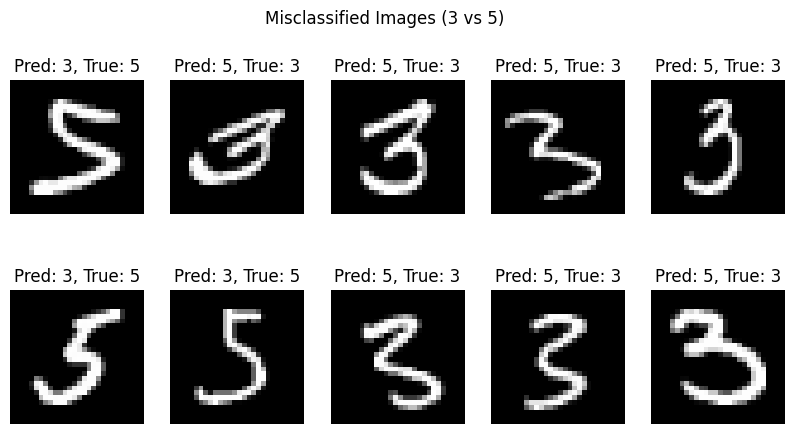

In [103]:
import matplotlib.pyplot as plt

# Predictions
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Find misclassified images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show first 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")

        # Convert back to original labels (3 or 5)
        true_label = 3 if y[idx] == 0 else 5
        pred_label = 3 if y_pred[idx] == 0 else 5

        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")

In this task, the perceptron model was used to classify handwritten digits 3 and 5, and it performed fairly well but not perfectly. The accuracy was decent, but some misclassifications still occurred, which is understandable because digits 3 and 5 can look quite similar, especially in handwritten form. From the misclassified images, it is clear that the model struggles when the digits are not clearly written or have overlapping features. This shows that the perceptron, being a simple linear model, has limitations when dealing with more complex patterns that are not linearly separable. Overall, the model works fine for basic classification, but more advanced methods would likely give better results for this kind of problem.